**Basophil**
Basophils play a role in allergic and parasitic reactions through the release of histamine and heparin. In leukemia, elevated basophil counts may indicate chronic myeloid leukemia (CML) or, in rare cases, proliferation in basophilic leukemia.

**Erythroblast**
Erythroblasts are precursor cells of red blood cells that mature in the bone marrow and transport oxygen. In leukemias such as erythroleukemia (AML M6), abnormal erythroblasts replace normal hematopoiesis and cause anemia.

**Eosinophil**
Eosinophils combat parasites and modulate allergic reactions through the release of granules. In leukemia, they appear in eosinophilic leukemia or AML M4Eo, where genetic aberrations drive their proliferation and may influence prognosis.

**Lymphocyte**
Lymphocytes are key immune cells responsible for adaptive immunity (B, T, and NK cells). In lymphoid leukemias such as ALL or CLL, malignant lymphocytes proliferate uncontrollably and suppress normal immune function.

**Metamyelocyte**
Metamyelocytes are immature granulocyte precursors in the process of maturing into neutrophils. In acute myeloid leukemias (AML), they appear in the blood as a sign of incomplete differentiation and contribute to leukocytosis.

**Monoblast**
Monoblasts are the earliest precursors of monocytes and macrophages in the bone marrow. In AML M5 (monoblastic leukemia), they predominate and lead to monocytosis with a high tendency to infiltrate tissues.

**Monocyte**
Monocytes differentiate into macrophages and dendritic cells for phagocytosis and antigen presentation. In myelomonocytic leukemia (AML M4/M5), malignant monocytes are increased and promote tissue destruction.

**Myelocyte**
Myelocytes are precursors of granulocytes (neutrophils, eosinophils, basophils) in the myeloid maturation pathway. In chronic myeloproliferative diseases or AML, they appear in peripheral blood and indicate disrupted hematopoiesis.

**Myeloblast**
Myeloblasts are pluripotent precursor cells of all myeloid lineages in the bone marrow. In AML (e.g., M1/M2), they exceed 20% of the blast population and block maturation, leading to severe leukopenia and susceptibility to infections.

**Neutrophil**
Neutrophils are the main effectors of the acute immune response against bacteria through phagocytosis and NETosis. In AML or CML, abnormal neutrophils may impair function and cause neutropenia with increased infection risk.

**Promyelocyte**
Promyelocytes are early granulocyte precursors containing azurophilic granules. In acute promyelocytic leukemia (APL, AML M3), they accumulate due to the t(15;17) translocation and cause coagulation disorders.

In [2]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random
import pandas as pd
import numpy as np


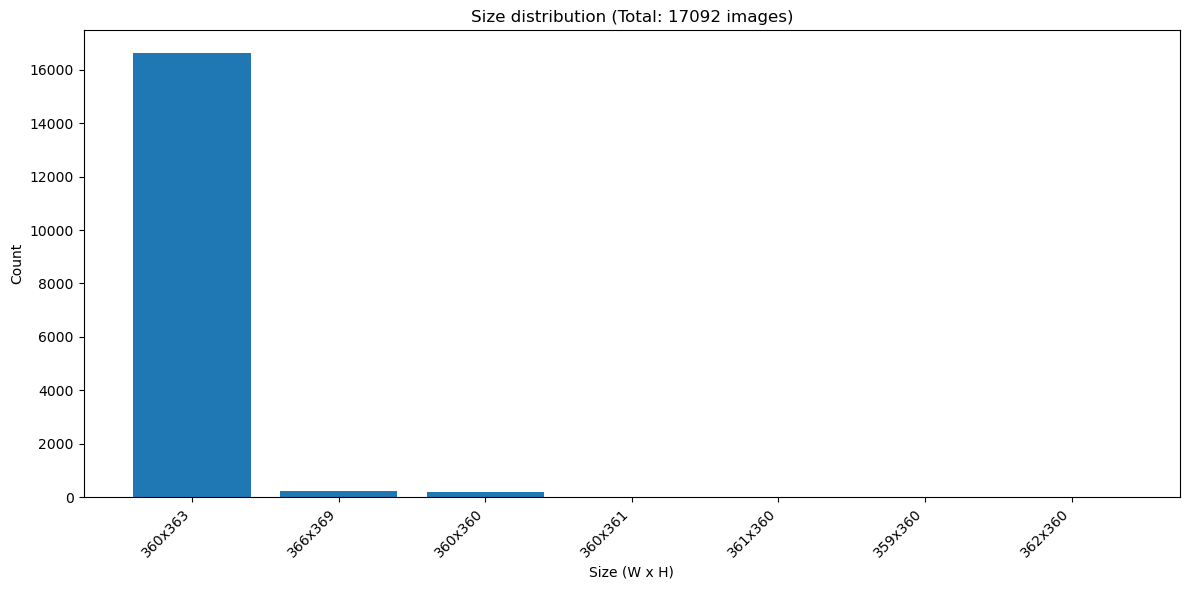

Total Images: 17092

Unique Sizes: 7
360x363: 16639 images (97.35%)
366x369: 250 images (1.46%)
360x360: 198 images (1.16%)
360x361: 2 images (0.01%)
361x360: 1 images (0.01%)
359x360: 1 images (0.01%)
362x360: 1 images (0.01%)


In [3]:
BASE_PATH = Path("Data/NormalCells/original")

sizes = []

for img_path in BASE_PATH.rglob("*.jpg"):
    try:
        with Image.open(img_path) as img:
            sizes.append(img.size) 
    except:
        pass

for img_path in BASE_PATH.rglob("*.png"):
    try:
        with Image.open(img_path) as img:
            sizes.append(img.size)
    except:
        pass

size_counts = Counter(sizes)

labels = [f"{w}x{h}" for w, h in size_counts.keys()]
counts = list(size_counts.values())

plt.figure(figsize=(12, 6))
plt.bar(range(len(labels)), counts)
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.xlabel('Size (W x H)')
plt.ylabel('Count')
plt.title(f'Size distribution (Total: {len(sizes)} images)')
plt.tight_layout()
plt.savefig('image_sizes.png', dpi=300)
plt.show()

print(f"Total Images: {len(sizes)}")
print(f"\nUnique Sizes: {len(size_counts)}")
for size, count in size_counts.most_common():
    print(f"{size[0]}x{size[1]}: {count} images ({count/len(sizes)*100:.2f}%)")

In [ ]:


def resize_centered_crop(img_path, output_path, size=300):
    with Image.open(img_path) as img:
        # Zentriertes Crop: 300x300 aus der Mitte
        left = (img.width - size) // 2
        top = (img.height - size) // 2
        right = left + size
        bottom = top + size
        
        cropped = img.crop((left, top, right, bottom))
        cropped = cropped.resize((size, size), Image.Resampling.LANCZOS)
        cropped.save(output_path)

def preprocess_images(input_dir="data", output_dir="data/cropped_pictures", size=300):
    """Crop alle Bilder: data/zelltyp_n/ --> data/cropped_pictures/zelltyp_n/"""
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)
    
    for zelltyp_folder in input_path.iterdir():
        if zelltyp_folder.is_dir():
            # Ziel-Unterordner erstellen
            new_zelltyp_folder = output_path / zelltyp_folder.name
            new_zelltyp_folder.mkdir(exist_ok=True)
            
            print(f"Verarbeite Zelltyp: {zelltyp_folder.name}")
            
            for img_file in zelltyp_folder.rglob("*"):
                if img_file.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}:
                    output_file = new_zelltyp_folder / img_file.name
                    
                    resize_centered_crop(img_file, output_file, size)
                    print(f"  {img_file.name}  300x300 gecroppt")
    
    print(f"\n done! {len(list(output_path.rglob('*.*')))} Bilder in {output_dir}/ gespeichert")


preprocess_images("Data/NormalCells/original", "Data/NormalCells/cropped_pictures", size=300)


Verarbeite Zelltyp: basophil
  BA_689200.jpg  300x300 gecroppt
  BA_883452.jpg  300x300 gecroppt
  BA_382161.jpg  300x300 gecroppt
  BA_175579.jpg  300x300 gecroppt
  BA_775722.jpg  300x300 gecroppt
  BA_209608.jpg  300x300 gecroppt
  BA_977935.jpg  300x300 gecroppt
  BA_95396.jpg  300x300 gecroppt
  BA_693714.jpg  300x300 gecroppt
  BA_878384.jpg  300x300 gecroppt
  BA_691117.jpg  300x300 gecroppt
  BA_240977.jpg  300x300 gecroppt
  BA_762060.jpg  300x300 gecroppt
  BA_347981.jpg  300x300 gecroppt
  BA_418760.jpg  300x300 gecroppt
  BA_727528.jpg  300x300 gecroppt
  BA_879878.jpg  300x300 gecroppt
  BA_238012.jpg  300x300 gecroppt
  BA_752996.jpg  300x300 gecroppt
  BA_482919.jpg  300x300 gecroppt
  BA_23839.jpg  300x300 gecroppt
  BA_535962.jpg  300x300 gecroppt
  BA_961010.jpg  300x300 gecroppt
  BA_77298.jpg  300x300 gecroppt
  BA_499861.jpg  300x300 gecroppt
  BA_620858.jpg  300x300 gecroppt
  BA_633824.jpg  300x300 gecroppt
  BA_391096.jpg  300x300 gecroppt
  BA_579017.jpg  300x3

In [4]:
print(BASE_PATH)

Data/NormalCells


In [ ]:
def resize_centered_crop(img_path, output_path, size=300):
    with Image.open(img_path) as img:
        # Zentriertes Crop: 300x300 aus der Mitte
        left = (img.width - size) // 2
        top = (img.height - size) // 2
        right = left + size
        bottom = top + size
        
        cropped = img.crop((left, top, right, bottom))
        cropped = cropped.resize((size, size), Image.Resampling.LANCZOS)
        cropped.save(output_path)

def preprocess_images(input_dir="data", output_dir="data/cropped_pictures", size=300):
    """Crop alle Bilder: data/zelltyp_n/*.jpg --> data/cropped_pictures/zelltyp_n/*.jpg"""
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)
    
    for zelltyp_folder in input_path.iterdir():  
        if zelltyp_folder.is_dir():
            # Ziel-Unterordner erstellen: cropped_pictures/zelltyp_n/
            new_zelltyp_folder = output_path / zelltyp_folder.name
            new_zelltyp_folder.mkdir(exist_ok=True)
            
            print(f"Verarbeite Zelltyp: {zelltyp_folder.name}")
            processed_count = 0
            
            for img_file in zelltyp_folder.iterdir():  
                if img_file.is_file() and img_file.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}:
                    # Gleicher Dateiname im neuen Ordner
                    output_file = new_zelltyp_folder / img_file.name
                    
                    resize_centered_crop(img_file, output_file, size)
                    print(f"  {img_file.name} --> 300x300 gecroppt")
                    processed_count += 1
            
            print(f"  --> {processed_count} Bilder verarbeitet")
    
    total_images = sum(len(list(folder.glob('*'))) for folder in output_path.iterdir() if folder.is_dir())
    print(f"\n done! {total_images} Bilder in {output_dir}/... gespeichert!")


preprocess_images("Data/NormalCells", "Data/NormalCells/cropped_pictures", size=300)


Finde 8 Zelltypen: basophil, eosinophil, erythroblast, ig, lymphocyte, monocyte, neutrophil, platelet


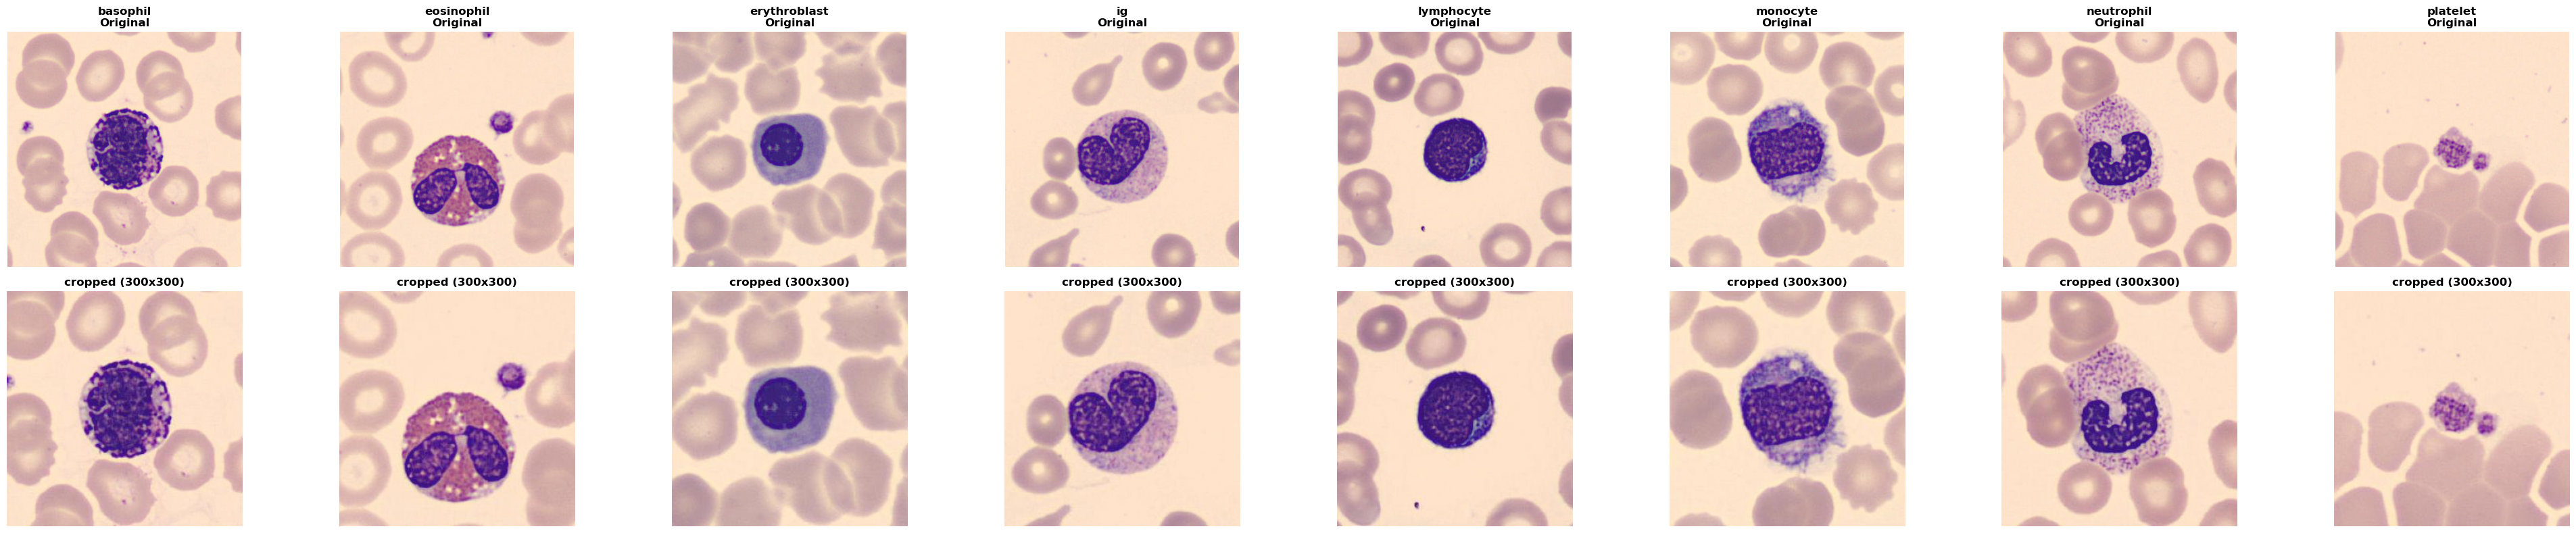

In [ ]:
def get_random_image(folder_path):
    image_files = [f for f in folder_path.iterdir() 
                   if f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}]
    if not image_files:
        return None
    return random.choice(image_files)

def create_comparison_plot(original_dir, cropped_dir):
    # Erstellt 2xN Subplot mit Original (oben) und gecroppt (unten)
    
    original_dir = Path(original_dir)
    cropped_dir = Path(cropped_dir)
    
    # Alle zelltyp_n Ordner ermitteln
    zelltypen = [f for f in original_dir.iterdir() if f.is_dir()]
    zelltypen.sort()  
    
    print(f"Finde {len(zelltypen)} Zelltypen: {', '.join(f.name for f in zelltypen)}")
    
    fig, axes = plt.subplots(2, len(zelltypen), figsize=(5*len(zelltypen), 8))

    
    for idx, zelltyp_folder in enumerate(zelltypen):
        zelltyp_name = zelltyp_folder.name
        
        orig_img_path = get_random_image(zelltyp_folder)
        # Gleiches Bild aus gecropptem Ordner
        cropped_img_path = cropped_dir / zelltyp_name / orig_img_path.name
        
        orig_img = Image.open(orig_img_path)
        axes[0, idx].imshow(orig_img)
        axes[0, idx].set_title(f'{zelltyp_name}\nOriginal', fontsize=12, fontweight='bold')
        axes[0, idx].axis('off')

        crop_img = Image.open(cropped_img_path)
        axes[1, idx].imshow(crop_img)
        axes[1, idx].set_title('cropped (300x300)', fontsize=12, fontweight='bold')
        axes[1, idx].axis('off')
    
    plt.tight_layout()
    plt.show()

original_dir = "Data/NormalCells/original"
cropped_dir = "Data/NormalCells/cropped_pictures"
create_comparison_plot(original_dir,cropped_dir)



Class distribution:
   cell type  count  percentage
  neutrophil   3329       19.48
  eosinophil   3117       18.24
          ig   2895       16.94
    platelet   2348       13.74
erythroblast   1551        9.07
    monocyte   1420        8.31
    basophil   1218        7.13
  lymphocyte   1214        7.10


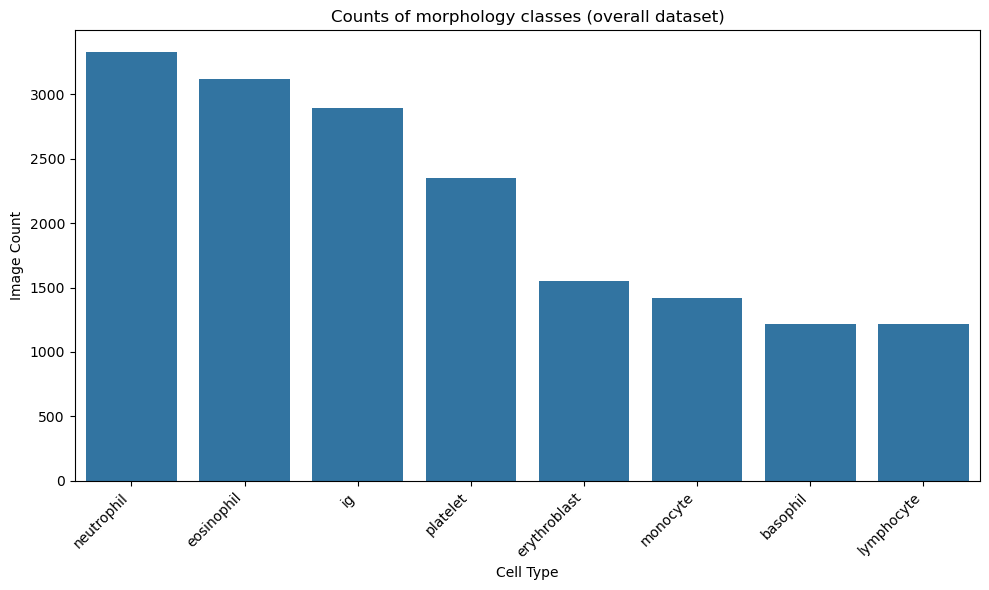

In [5]:
ROOT_DIR = Path.cwd() /'Data'/'NormalCells'/'cropped_pictures' 
IMG_EXTS = {".jpg", ".jpeg",".tiff"}

class_counts = {}

for subfolder in ROOT_DIR.iterdir():
    if not subfolder.is_dir():
        continue
    class_name = subfolder.name
    img_files = [
        f for f in subfolder.iterdir()
        if f.is_file() and f.suffix.lower() in IMG_EXTS
    ]
    class_counts[class_name] = len(img_files)

df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["cell type", "count"]
)

df_counts = df_counts.sort_values("count", ascending=False).reset_index(drop=True)

df_counts["percentage"] = round(100 * df_counts["count"] / df_counts["count"].sum(), 2)

print("\nClass distribution:")
print(df_counts.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=df_counts, x="cell type", y="count")
plt.title("Counts of morphology classes (overall dataset)")
plt.xlabel("Cell Type")
plt.ylabel("Image Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [1]:
print(df_counts.head(10))


NameError: name 'df_counts' is not defined

In [31]:
def analyze_image_rgb(img_path):
    img = Image.open(img_path)
    if img.mode != "RGB":
        img = img.convert("RGB")
    arr = np.array(img).astype(np.float32)  # [H, W, 3]

    gray = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]
    mean_intensity = np.mean(gray)
    std_intensity = np.std(gray)

    r, g, b = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
    stats = {
        "mean_r": np.mean(r),
        "std_r": np.std(r),
        "min_r": np.min(r),
        "max_r": np.max(r),
        "mean_g": np.mean(g),
        "std_g": np.std(g),
        "min_g": np.min(g),
        "max_g": np.max(g),
        "mean_b": np.mean(b),
        "std_b": np.std(b),
        "min_b": np.min(b),
        "max_b": np.max(b),
    }

    return mean_intensity, std_intensity, stats

In [32]:
MAX_IMAGES_PER_CLASS = 10000
results = []

for class_name in os.listdir(ROOT_DIR):
    class_path = os.path.join(ROOT_DIR, class_name)
    if not os.path.isdir(class_path):
        continue

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tiff"))
    ]

    sampled_files = random.sample(
        image_files,
        min(MAX_IMAGES_PER_CLASS, len(image_files))
    )

    for img_file in sampled_files:
        img_path = os.path.join(class_path, img_file)
        mean_int, std_int, rgb_stats = analyze_image_rgb(img_path)

        row = {
            "class": class_name,
            "filename": img_file,
            "mean_intensity": mean_int,
            "std_intensity": std_int,
        }
        row.update(rgb_stats)
        results.append(row)


df = pd.DataFrame(results)

In [33]:

print("\nColor statistics per class (mean RGB values):")
print(df.groupby("class")[["mean_r", "mean_g", "mean_b"]].agg("mean"))


Color statistics per class (mean RGB values):
                  mean_r      mean_g      mean_b
class                                           
basophil      214.274796  181.113800  181.344208
eosinophil    217.497757  182.519516  180.237595
erythroblast  224.951126  194.663147  186.028351
ig            211.274307  178.790070  181.093109
lymphocyte    219.370621  187.590012  182.576736
monocyte      209.397598  176.584167  180.600220
neutrophil    218.119217  185.140488  181.494675
platelet      232.286819  200.836411  186.880127


In [34]:

df_rgb = df.groupby("class")[["mean_r", "mean_g", "mean_b"]].agg("mean").reset_index()
df_rgb.head(8)

,class,mean_r,mean_g,mean_b
0,basophil,214.274796,181.113800,181.344208
1,eosinophil,217.497757,182.519516,180.237595
2,erythroblast,224.951126,194.663147,186.028351
3,ig,211.274307,178.790070,181.093109
4,lymphocyte,219.370621,187.590012,182.576736
5,monocyte,209.397598,176.584167,180.600220
6,neutrophil,218.119217,185.140488,181.494675
7,platelet,232.286819,200.836411,186.880127


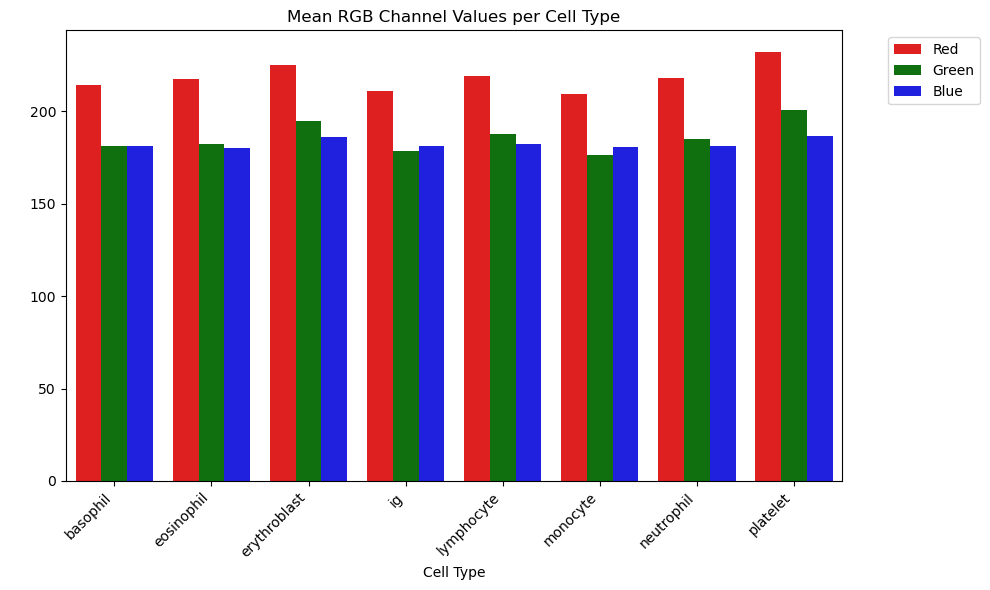

In [35]:

df_long = pd.melt(
    df_rgb,
    id_vars="class",
    value_vars=["mean_r", "mean_g", "mean_b"],
    var_name="channel",
    value_name="mean_pixel_value"
)

df_long["channel"] = df_long["channel"].map(
    {"mean_r": "Red", "mean_g": "Green", "mean_b": "Blue"}
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_long,
    x="class",
    y="mean_pixel_value",
    hue="channel",
    palette=["red", "green", "blue"],
)
plt.title("Mean RGB Channel Values per Cell Type")
plt.xlabel("Cell Type")
plt.ylabel(" ")
# plt.ylabel("Mean Pixel Value")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Channel")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [36]:
df_bc = df.groupby("class")[["mean_intensity", "std_intensity"]].agg("mean").reset_index()
df_bc.head(8)

,class,mean_intensity,std_intensity
0,basophil,191.055206,52.144390
1,eosinophil,192.717865,47.591007
2,erythroblast,202.734863,41.569389
3,ig,188.765411,51.006493
4,lymphocyte,196.520905,46.516350
5,monocyte,186.853210,48.980198
6,neutrophil,194.585495,44.069553
7,platelet,208.649063,28.608553


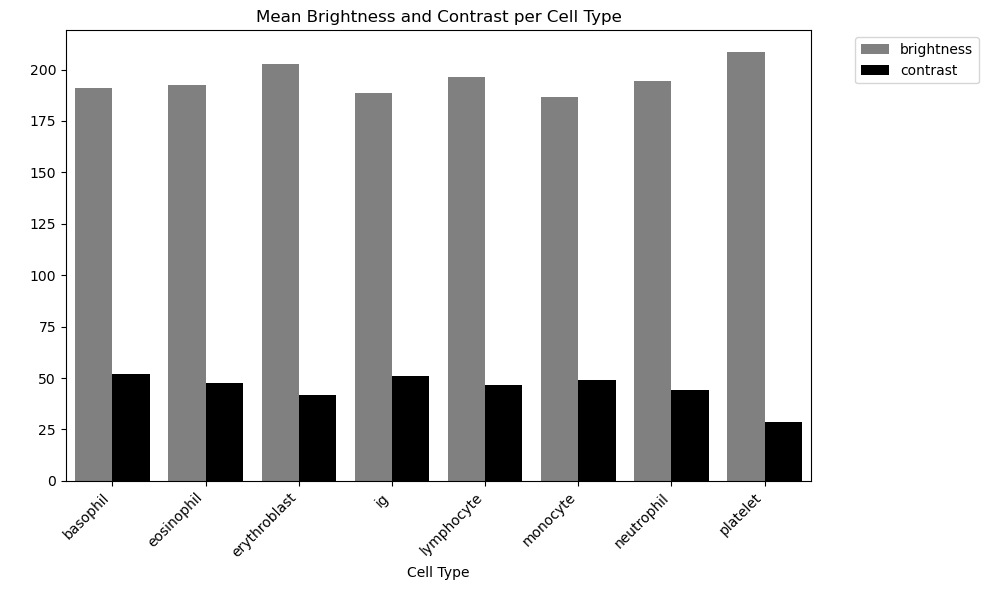

In [37]:

df_long = pd.melt(
    df_bc,
    id_vars="class",
    value_vars=["mean_intensity", "std_intensity"],
    var_name="var_type",
    value_name="mean_pixel_value"
)

df_long["var_type"] = df_long["var_type"].map(
    {"mean_intensity": "brightness", "std_intensity": "contrast"}
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_long,
    x="class",
    y="mean_pixel_value",
    hue="var_type",
    palette=["grey", "black"],
)
plt.title("Mean Brightness and Contrast per Cell Type")
plt.xlabel("Cell Type")
plt.ylabel(" ")
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

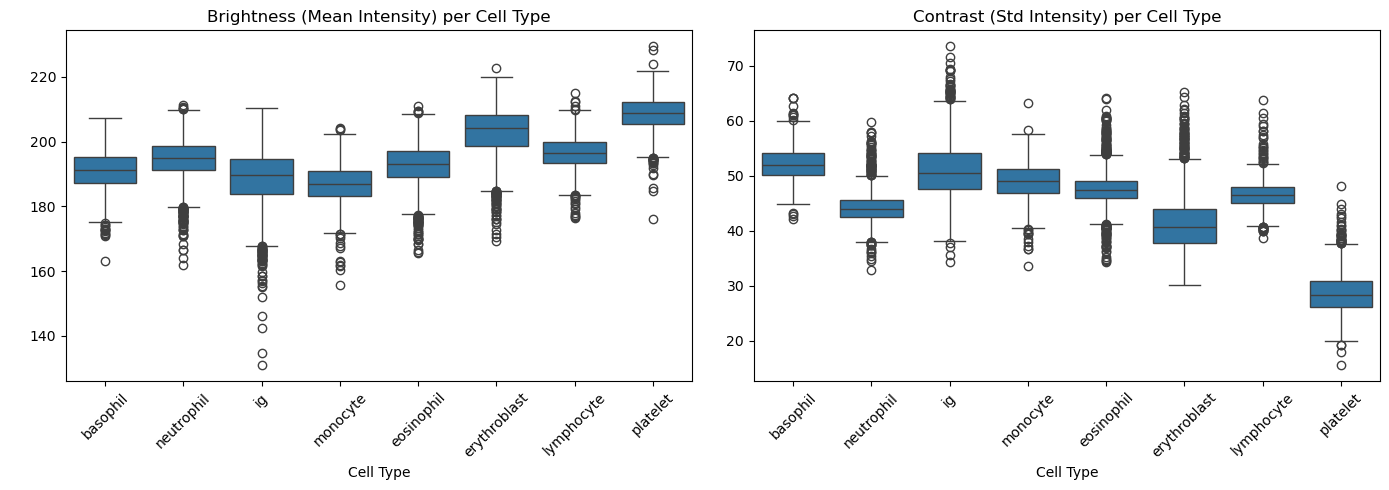

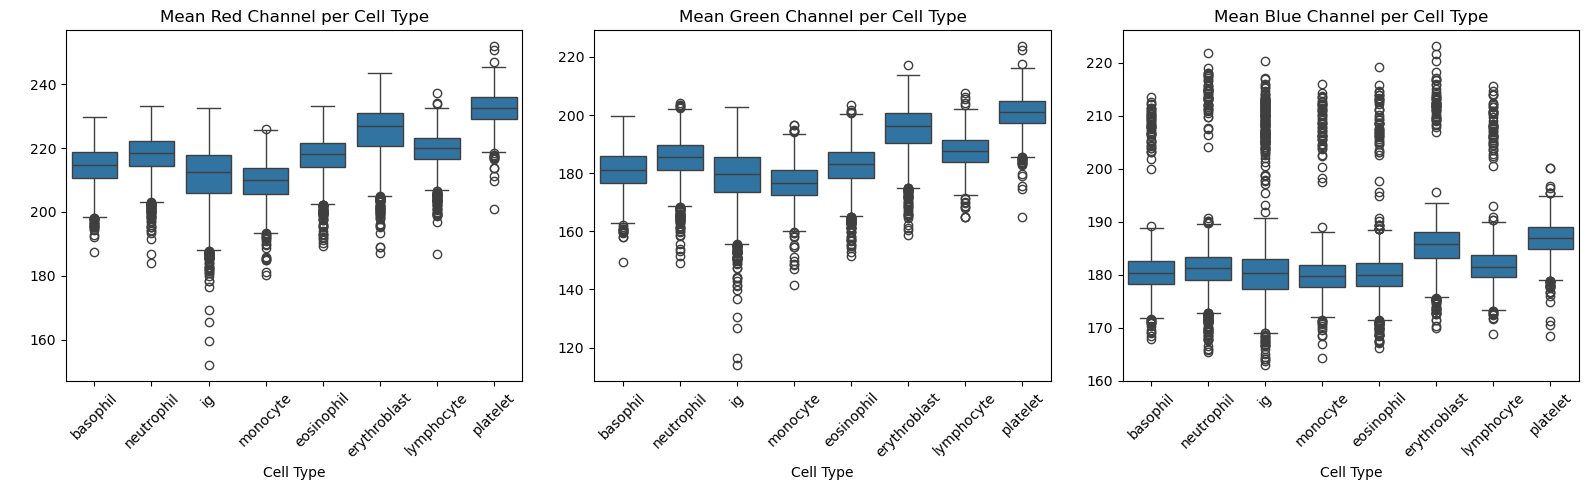

In [38]:

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="class", y="mean_intensity")
plt.title("Brightness (Mean Intensity) per Cell Type")
plt.ylabel(' ')
plt.xlabel('Cell Type')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="class", y="std_intensity")
plt.title("Contrast (Std Intensity) per Cell Type")
plt.ylabel(' ')
plt.xlabel('Cell Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 2) Boxplots für RGB‑Mittelwerte pro Klasse
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=df, x="class", y="mean_r")
plt.title("Mean Red Channel per Cell Type")
plt.xlabel('Cell Type')
plt.ylabel(' ')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
sns.boxplot(data=df, x="class", y="mean_g")
plt.title("Mean Green Channel per Cell Type")
plt.xlabel('Cell Type')
plt.ylabel(' ')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x="class", y="mean_b")
plt.title("Mean Blue Channel per Cell Type")
plt.xlabel('Cell Type')
plt.ylabel(' ')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
